Build a classification model to predict whether a loan application will be approved or rejected based on applicant details.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('loan_data.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [5]:
df.shape

(381, 13)

In [6]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

Credit_History       30
Self_Employed        21
Loan_Amount_Term     11
Dependents            8
Gender                5
Loan_ID               0
Married               0
Education             0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df.nunique()

Loan_ID              381
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      322
CoapplicantIncome    182
LoanAmount           101
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

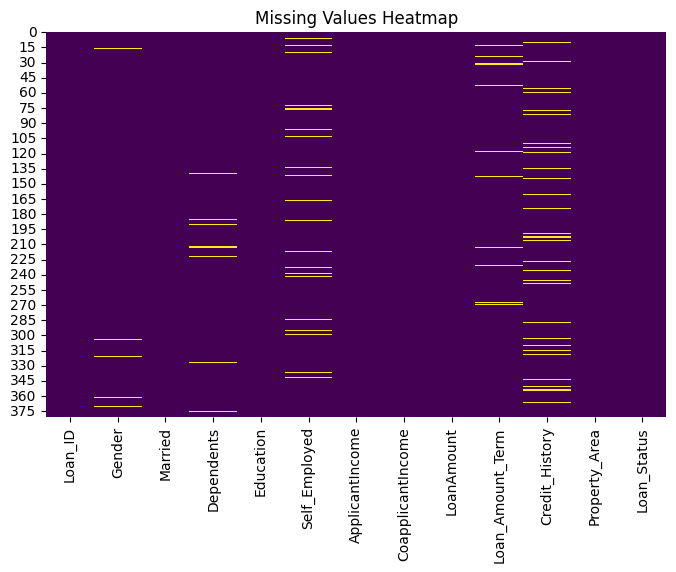

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
df['Loan_Status'].value_counts()

Loan_Status
Y    271
N    110
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\4211394554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


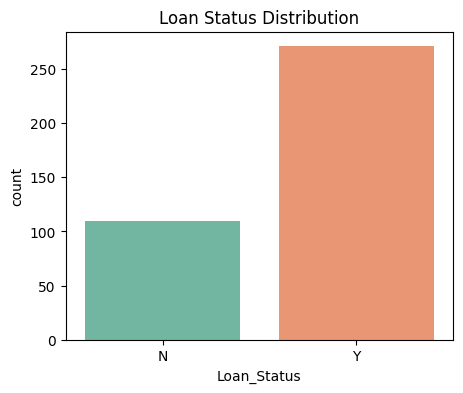

In [13]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title("Loan Status Distribution")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


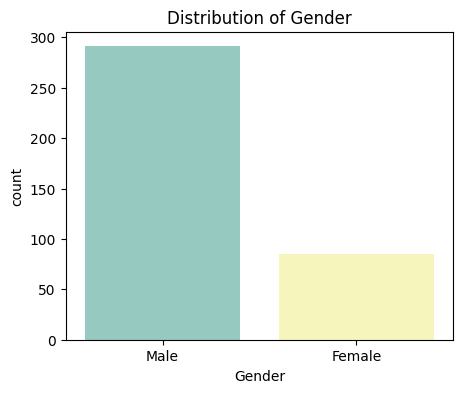

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


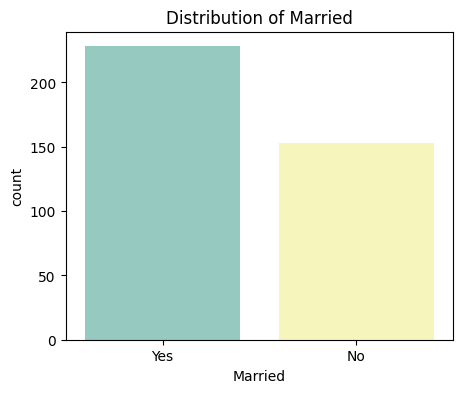

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


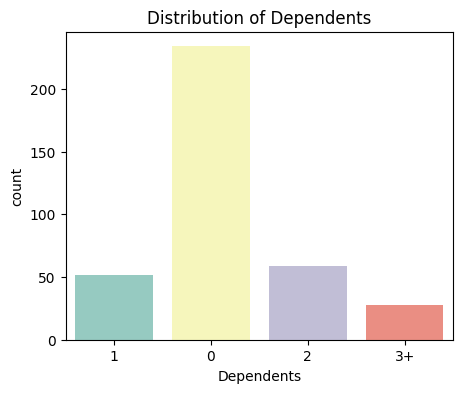

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


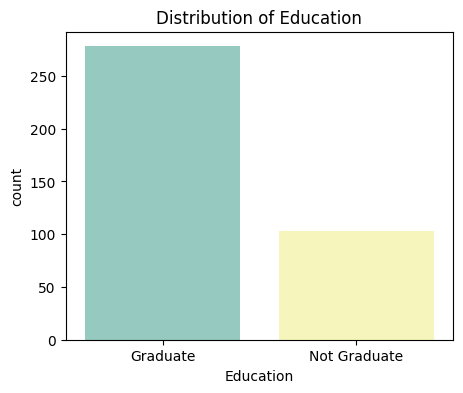

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


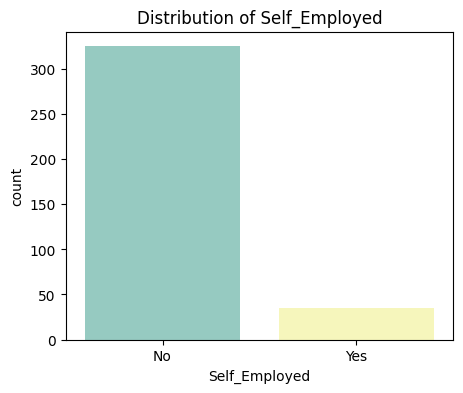

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


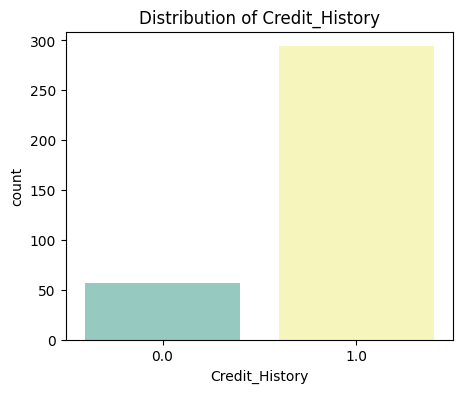

C:\Users\Admin\AppData\Local\Temp\ipykernel_6092\1864006589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set3')


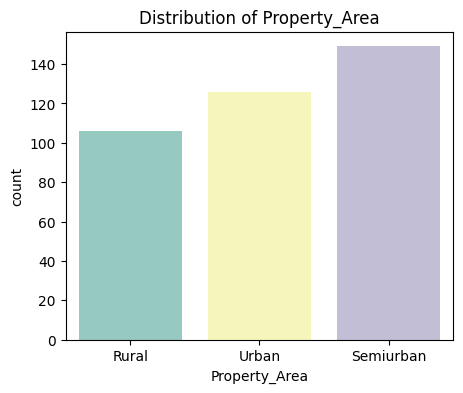

In [14]:
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

for col in categorical_features:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=col, data=df, palette='Set3')
    plt.title(f"Distribution of {col}")
    plt.show()

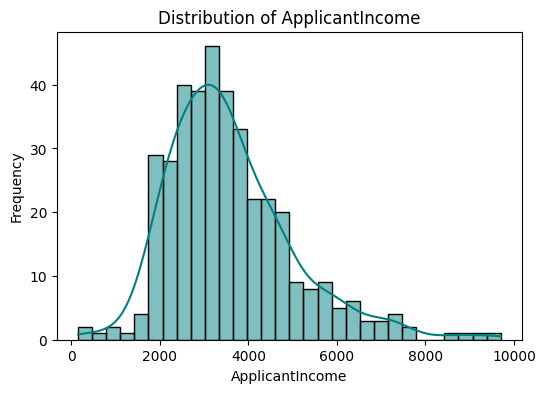

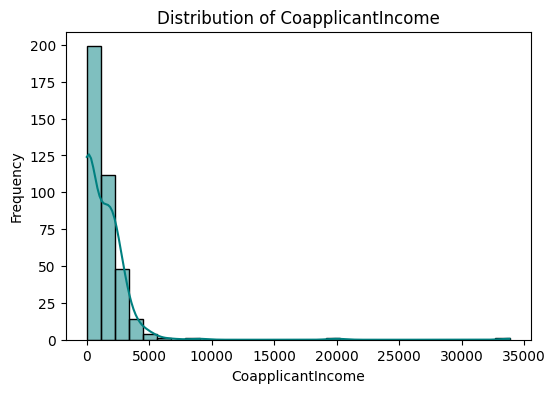

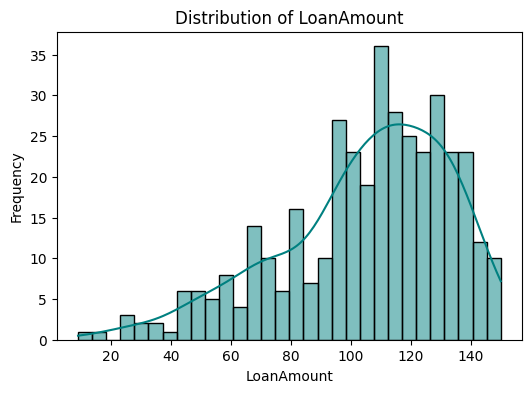

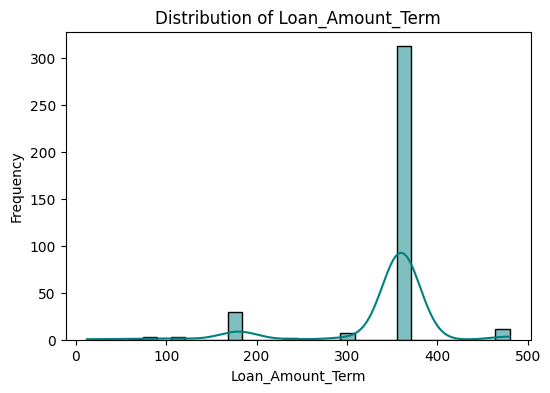

In [15]:
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True, color='teal')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

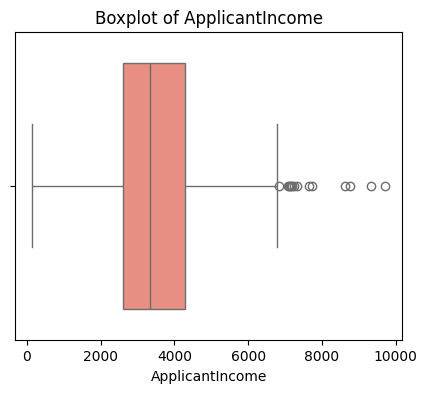

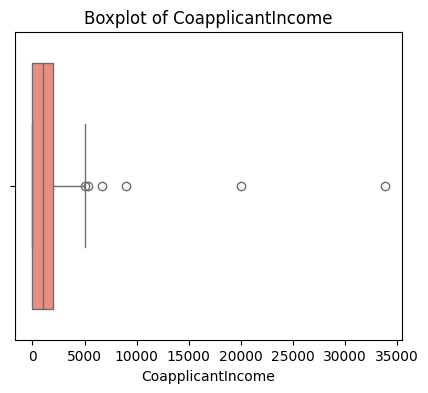

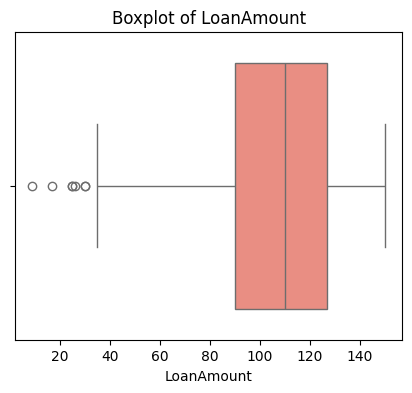

In [16]:
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f"Boxplot of {col}")
    plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [18]:
df.drop('Loan_ID', axis=1, inplace=True)

In [19]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [20]:
# Categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [21]:
# Numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit and transform on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform on test data
X_test_processed = preprocessor.transform(X_test)

# Confirm shapes
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)


Processed X_train shape: (304, 20)
Processed X_test shape: (77, 20)


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [25]:
dt_model = DecisionTreeClassifier(random_state=42)

In [26]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])

In [27]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn import tree

In [29]:
y_pred = model_pipeline.predict(X_test)

In [30]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

In [31]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7922
Precision: 0.8545
Recall: 0.8545
F1 Score: 0.8545


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.64      0.64        22
           1       0.85      0.85      0.85        55

    accuracy                           0.79        77
   macro avg       0.75      0.75      0.75        77
weighted avg       0.79      0.79      0.79        77



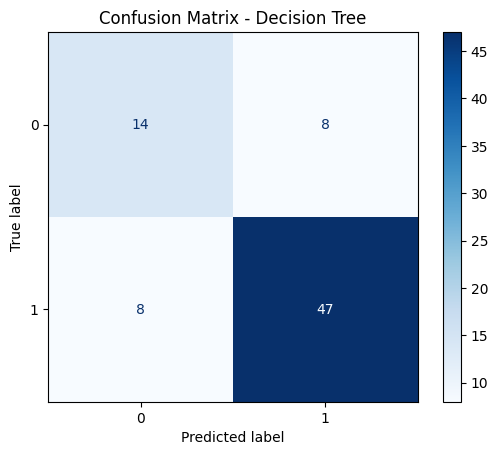

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_pipeline.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()


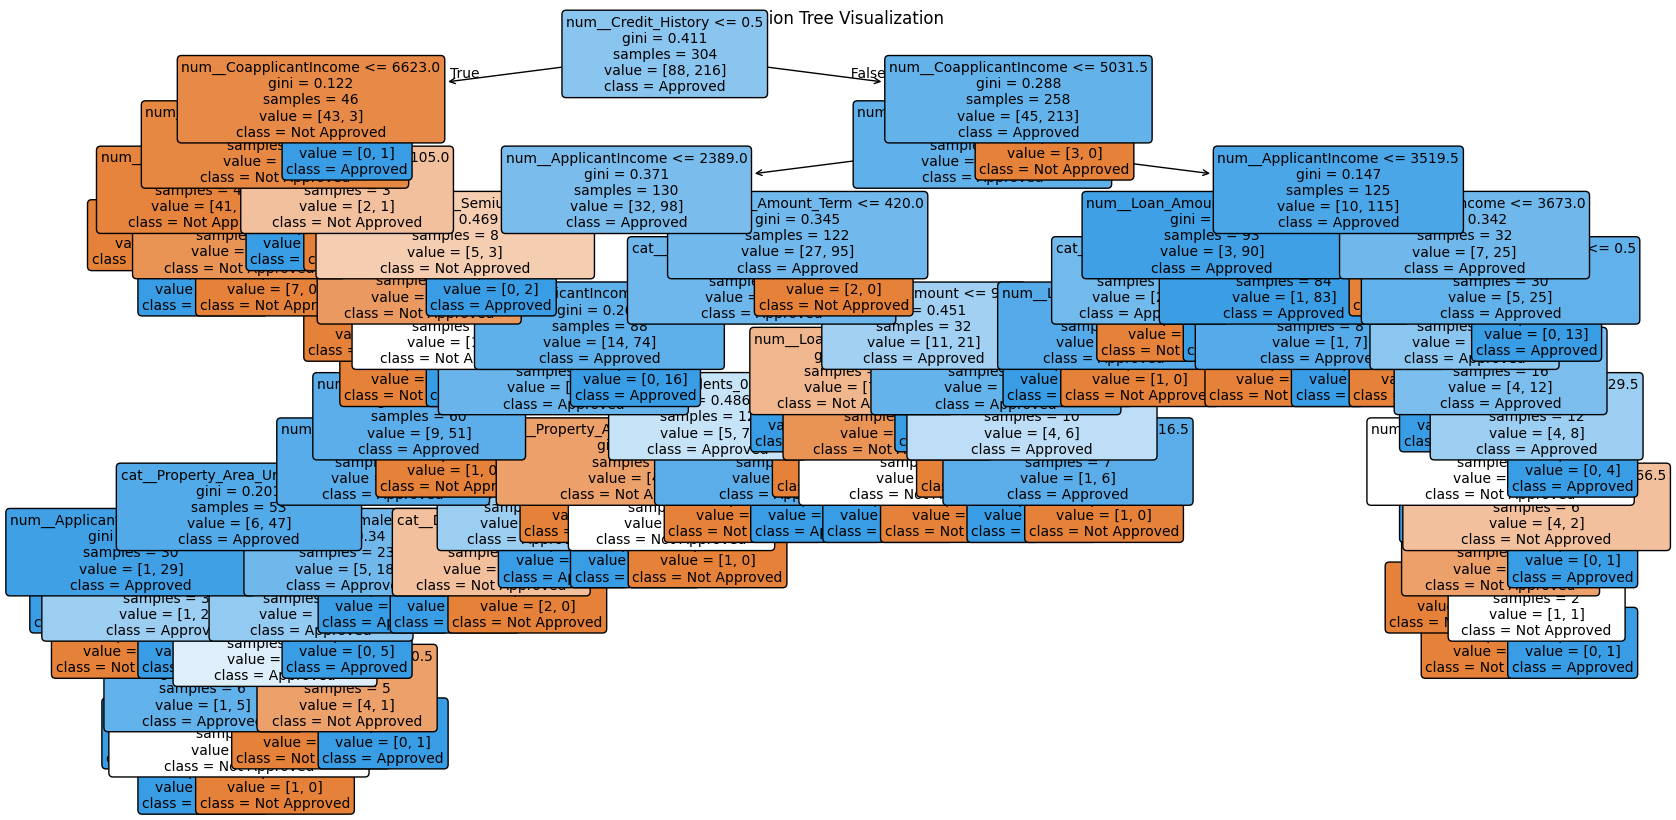

In [34]:
# Extract the trained Decision Tree from the pipeline
trained_dt = model_pipeline.named_steps['classifier']

# Visualize the tree
plt.figure(figsize=(20, 10))
tree.plot_tree(
    trained_dt,
    filled=True,
    feature_names=model_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    class_names=['Not Approved', 'Approved'],
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
    'classifier__max_depth': [3, 5, 7, 9, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

In [38]:
# Wrap the existing pipeline in GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,                        # 5-fold cross-validation
    scoring='accuracy',          # Can use 'roc_auc' if preferred
    n_jobs=-1,                   # Use all available cores
    verbose=2
)

In [39]:
# Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Best cross-validation accuracy
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Hyperparameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV Accuracy: 0.8191


In [40]:
# Predict on test data using the best estimator
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
y_pred_proba_tuned = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"Tuned Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Precision: {precision_tuned:.4f}")
print(f"Tuned Recall: {recall_tuned:.4f}")
print(f"Tuned F1 Score: {f1_tuned:.4f}")


Tuned Accuracy: 0.8571
Tuned Precision: 0.8438
Tuned Recall: 0.9818
Tuned F1 Score: 0.9076


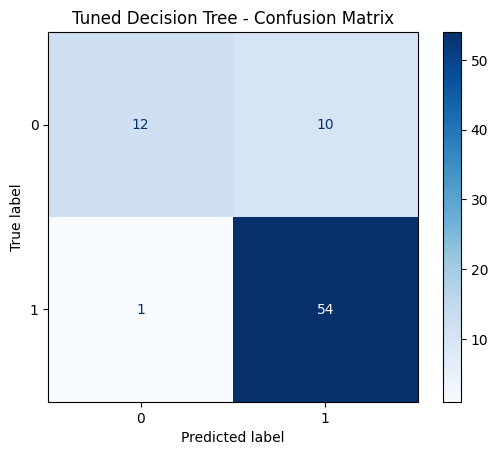

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test, cmap='Blues')
plt.title("Tuned Decision Tree - Confusion Matrix")
plt.show()

In [42]:
import joblib

# Save the best estimator (pipeline + tuned Decision Tree)
joblib.dump(grid_search.best_estimator_, 'model.pkl')


['model.pkl']